In [4]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append("..")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models

from src.data import ACTIVIDADES, CORRECCIONES, parsear_nombre
from src.preprocessing import preparar_espectrograma
from src.resNetEspectro import ResNetEspectro

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 6)
modelo = ResNetEspectro(resnet)

pesos = torch.load("../models/resnet18_finetune_5s.pt", map_location=device)
modelo.load_state_dict(pesos)
modelo.to(device).eval()

ResNetEspectro(
  (modelo): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-0

In [6]:
def predecir(ruta):
    grabacion = np.load(ruta)
    imagen = preparar_espectrograma(grabacion["senal"], float(grabacion["t_chirp"]))
    x = torch.tensor(imagen).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(modelo(x), dim=1)[0].cpu().numpy()
    return imagen, probs

def actividad_real(ruta):
    gid = os.path.splitext(os.path.basename(ruta))[0]
    nombre = gid.split("_", 1)[1]
    return CORRECCIONES.get(gid, parsear_nombre(nombre)["actividad"])

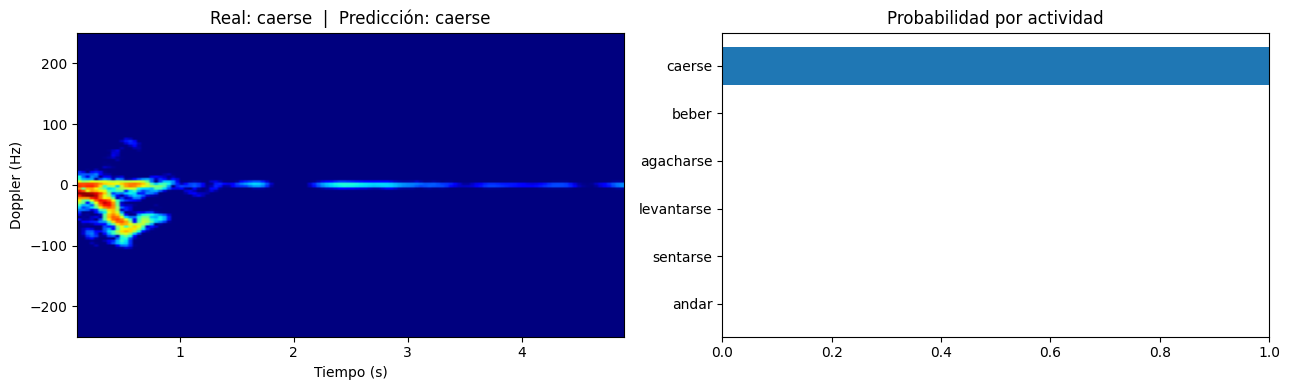

In [7]:
ruta = "../data/processed/senales/C1_6P44A06R02.npz"

imagen, probs = predecir(ruta)
pred = probs.argmax() + 1
real = actividad_real(ruta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.imshow(imagen, origin="lower", aspect="auto", cmap="jet", extent=[0.1, 4.9, -250, 250])
ax1.set_title(f"Real: {ACTIVIDADES[real]}  |  Predicción: {ACTIVIDADES[pred]}")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Doppler (Hz)")

ax2.barh([ACTIVIDADES[i + 1] for i in range(6)], probs)
ax2.set_xlim(0, 1)
ax2.set_title("Probabilidad por actividad")
plt.tight_layout()
plt.show()